In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [44]:
df = pd.read_csv("email.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [45]:
df.isna().sum()

Category    0
Message     0
dtype: int64

In [46]:
df['Category'].value_counts()

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

### Ham here refers to legit emails that isn't spam

In [47]:
df = df[df["Category"] != '{"mode":"full"']

In [48]:
df.shape

(5572, 2)

Text(0.5, 1.0, 'Spam vs Ham Counts')

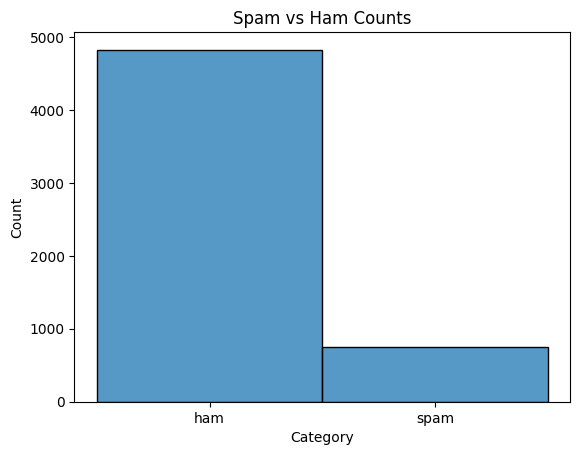

In [7]:
sns.histplot(data=df, x='Category')
plt.title("Spam vs Ham Counts")


In [49]:
df["Category"] =df["Category"].map({"spam": 1, "ham": 0})
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

In [12]:
X = df['Message']
y = df['Category']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [ ]:
base = MultinomialNB()
Vectorizer = TfidfVectorizer()

In [16]:
pipeline = Pipeline(steps=[
    ("vectorization", Vectorizer),
    ('Model', base)
    
])

In [23]:
params = {'Model__alpha': [0.1,0.25,0.5,0.75,1,2,3,4,5]}
GS = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    scoring='accuracy'
)

In [24]:
GS.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...inomialNB())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'Model__alpha': [0.1, 0.25, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and

In [25]:
GS.best_params_

{'Model__alpha': 0.1}

In [26]:
model = GS.best_estimator_

In [27]:
ypred=GS.best_estimator_.predict(X_test)
accuracy_score(ypred, y_test)


0.9811659192825112

In [28]:
mess = """Dear Winner,

Congratulations!!! Your email address has been selected in our International Lottery Draw.

You have won $5,000,000 USD.

To claim your prize, please reply immediately with the following details:

Full Name
Address
Phone Number
Bank Account Information

You must respond within 24 hours or your winnings will be forfeited.

Kind regards,
Dr. Michael Johnson
Claims Officer
Global Lottery Commission"""
message = {"Message": mess}
message

{'Message': 'Dear Winner,\n\nCongratulations!!! Your email address has been selected in our International Lottery Draw.\n\nYou have won $5,000,000 USD.\n\nTo claim your prize, please reply immediately with the following details:\n\nFull Name\nAddress\nPhone Number\nBank Account Information\n\nYou must respond within 24 hours or your winnings will be forfeited.\n\nKind regards,\nDr. Michael Johnson\nClaims Officer\nGlobal Lottery Commission'}

# Exporting Model


In [59]:
import joblib

In [67]:
joblib.dump(model, filename="Spam-detection.pkl")

['Spam-detection.pkl']